# POC — `fedwater_lab` end to end

A thin driver. Everything substantive lives in `fedwater_lab/`; this notebook picks a
**cached world** (browsing by districting method), chooses **which sensors** the clients use
(and shows why each one is there), runs a cell, checks the artifact contract, scores, plots,
and — new — **decodes the prototypes back into window space** to see what they remember.

| module | owns |
|---|---|
| `bridge` | the only import seam to `fedwater` — nothing upstream is re-implemented |
| `worlds` | world dir → params merge, ground truth, phases; partition, `sensor_placement`, `list_worlds` / `pick_world` |
| `specs` | the experiment axes as data; `CellSpec.key()` is the run identity; sensor selection = `kinds` × `classes` + `include` / `exclude` |
| `data` | selection (`sensor_table`) → transform → windows → scaling |
| `train` | one `SnapshotFPLTrainer`; `decode` / `reconstruct_prototypes` |
| `store` | two layers — immutable `runs/`, appendable `scores/` |
| `metrics` | one definition of every latent / probe / drift metric |
| `cluster` | similarity + partition, one `(scope, round, phase)` slice at a time |
| `recon` | decoded prototypes vs sensors vs demand; phases; mixture retrieval; FINCH membership |
| `figures` / `widgets` | pure `df → Axes`, plus thin ipywidgets wiring |

**Needs:** worlds built by the current pipeline (they carry `sensor_placement.csv` and a
partition). Worlds from before the dynamic-sensors refactor cannot be loaded.

## 0. Setup

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# <repo>/src must be importable: the lab borrows fedwater's own code.
REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"

# The directory that CONTAINS the `fedwater_lab/` package -- adjust to your layout.
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"

for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, list_worlds, pick_world
from fedwater_lab.store import Store
from fedwater_lab.specs import POC, CellSpec, expand, Geometry
from fedwater_lab.runner import run_cell, run_grid
from fedwater_lab import data as D, metrics as M, cluster as C, figures as F
from fedwater_lab import recon as RC, train as T, widgets as WGT

EXPERIMENTS = REPO / "data" / "09_experiments"
pd.set_option("display.width", 200, "display.max_columns", 40)
print(f"repo {REPO}")

repo c:\Users\arthu\USPy\10_Mestrado\fedWater


## 1. World — browse the cache, pick by districting method

`list_worlds` reads each cached world's `manifest.json` only (no clone is opened), so this is
cheap over any number of worlds. The columns are the world's identity as the engine recorded
it: `districting` (partition method), `partition_id` (the partition's **content** — two
worlds with the same method but a rebuilt, different cut differ here), `placement_source`
(`dynamic` = sensors chosen by the probe stacks, `manual` = the profile's hand-placed set).

`pick_world(**filters)` returns the one world matching every filter and refuses if zero or
several match — tighten the filters rather than guess.

In [2]:
WORLDS = list_worlds(EXPERIMENTS)
display(WORLDS.drop(columns=["path", "created_utc"]))

# choose -- any column of the table above can be a filter
DISTRICTING = "spectral"                 # manual | spectral | girvan_newman | fast_greedy | walktrap
FILTERS = dict(sim_hash = "ece8f4ad92e5",  placement_source="dynamic",
            #    districting=DISTRICTING, n_months=55
               )

WORLD_DIR = pick_world(EXPERIMENTS, **FILTERS)
world = load_world(WORLD_DIR)
store = Store(LAB_DIR / "lab_sandbox")
print(world.summary().to_string())

,sim_hash,network,districting,partition_id,placement_source,drift_district,consumption_map,beta,n_months,days_per_month,seasonality_scale,variant,sim_seed,status,seconds
0,16ce72c589df,ky72,girvan_newman,6f359aad,dynamic,District_A,LR_LR_LR_LR,0.35,65,14,0.0,baseline,42,ok,653.7
1,ece8f4ad92e5,ky72,spectral,29fddafe,dynamic,District_A,LR_LR_LR_LR,0.35,65,14,0.0,baseline,42,ok,703.7


sim_hash                                 ece8f4ad92e5
tag                 District_A__LR_LR_LR_LR__baseline
network                                          ky72
districting                                  spectral
partition_id                                 29fddafe
placement_source                              dynamic
n_months                                           65
resolution_h                                        1
steps_day                                          24
clients                                             4
n_sensors                                          32
n_pure                                             16
n_mixed                                            16
drift_district                             District_A
warmup_months                                      12
first_switch                                       12
last_switch                                        63
ramp_days                                         7.0
init_months                 

Read the summary carefully: **the label-clean stretches can be short.** `init` ends at the
first node switch; `final` starts once the last switch has finished its ramp; everything in
between is transition and belongs to neither. The partition below is the one this world was
built on (read from the world's own clone).

partition spectral (29fddafe): k=4, sizes={'District_A': 215, 'District_B': 206, 'District_C': 30, 'District_D': 30}, boundary links=57, contiguous=True

ground truth, derived two ways (asserted equal at load):
  income_landuse_mapping     {'District_A': 'LR', 'District_B': 'LR', 'District_C': 'LR', 'District_D': 'LR'}
  consumption_map            {'District_A': 'LR', 'District_B': 'LR', 'District_C': 'LR', 'District_D': 'LR'}


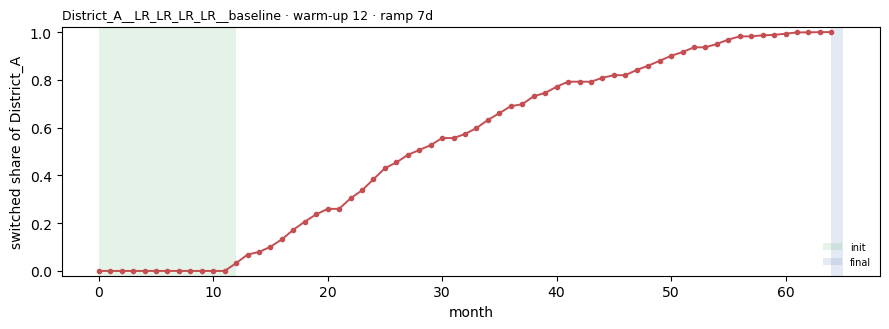

In [3]:
info = world.partition_info()
print(f"partition {info['method']} ({world.partition_id}): k={info['k']}, "
      f"sizes={info['sizes']}, boundary links={info['n_boundary_links']}, "
      f"contiguous={info['all_contiguous']}")
print("\nground truth, derived two ways (asserted equal at load):")
for s, mapping in world.regime_sources.items():
    print(f"  {s:<26} {mapping}")

fig, ax = plt.subplots(figsize=(9, 3.4))
F.plot_drift_progress(ax, world)
fig.tight_layout()

## 1b. Sensors — which, and why

Selection is three filters over the world's `sensor_placement.csv`, in order:

1. `kinds` — pressure / flow.
2. `classes` — `pure` / `mixed` slots (ignored on a `manual` world, which has no classes).
3. `include` / `exclude` — explicit sensor ids, applied last (`include` forces a sensor in
   even if 1–2 dropped it; `exclude` removes it even if they kept it).

The table is the **reason** each sensor is there, straight from the placement:

| column | meaning |
|---|---|
| `slot` / `slot_class` | the client-CSV column and the class of slot it fills (identical slot names in every client ⇒ channel *i* means the same slot everywhere) |
| `filled_as` | how the slot was filled: `pure` / `mixed` by the rule, or the fill ladder (`pure_redundant`, `mixed_redundant`, `pure_fill`, `best_available`, `unresponsive`) |
| `purity` | share of the sensor's response that comes from its own district: $w_{i,\text{home}}$ |
| `w_District_k` | the label mixture: share of district *k* in the sensor's response, $\sum_k w_{ik}=1$ over responsive districts |
| `second`, `w_second` | the largest foreign district and its share |
| `tier` | `core` (purity ≥ 0.85), `transition`, `foreign` (purity < 0.15), `unusable` (no response cleared noise) |
| `note` | why this spec kept it: `kind+class` (passed the filters) or `include` (forced in) |

In [4]:
from fedwater_lab.specs import Geometry, TrainCfg

SELECTION = dict(
    kinds=("flow",),
    classes=("pure", "mixed"),
    # geometry=Geometry(interval_agg_h=2, window_size=84, step_size=12),
    training=TrainCfg(rounds=15, fl_seed=0),
    include=(),          # e.g. ("q_P-260",)
    exclude=(
        # 'q_P-291','q_P-204',
        #      'q_P-259', 'q_P-30',
        #      'q_P-339', 'q_P-475',
        #      'q_P-10', 'q_P-42'
             ),          # e.g. ("p_J-65", "p_J-455")
)
spec = POC.with_(**SELECTION)

why = ["district", "kind", "slot", "slot_class", "filled_as", "note", "sensor",
       "tier", "purity", "second", "w_second"]
wcols = [c for c in world.sensor_placement.columns if c.startswith("w_District")]
kept = D.sensor_table(world, spec)
print(f"{len(kept)} sensors selected ({world.placement_source} world); per client:")
display(kept.groupby(["district", "kind", "slot_class"]).size().unstack(["kind", "slot_class"]))
display(kept[[c for c in why + wcols if c in kept.columns]].round(3))
dropped = D.dropped_table(world, spec)
if len(dropped):
    print("dropped:", dropped["note"].value_counts().to_dict())

16 sensors selected (dynamic world); per client:


kind        flow     
slot_class mixed pure
district             
District_A     2    2
District_B     2    2
District_C     2    2
District_D     2    2

,district,kind,slot,slot_class,filled_as,note,sensor,tier,purity,second,w_second,w_District_A,w_District_B,w_District_C,w_District_D
0,District_A,flow,q_mixed_0,mixed,mixed,kind+class,q_P-558,foreign,0.000,District_B,0.725,0.000,0.725,0.275,0.000
1,District_A,flow,q_mixed_1,mixed,mixed,kind+class,q_P-10,transition,0.272,District_D,0.728,0.272,0.000,0.000,0.728
2,District_A,flow,q_pure_0,pure,pure,kind+class,q_P-42,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000
3,District_A,flow,q_pure_1,pure,pure,kind+class,q_P-556,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000
4,District_B,flow,q_mixed_0,mixed,mixed,kind+class,q_P-605,foreign,0.000,District_A,0.656,0.656,0.000,0.344,0.000
5,District_B,flow,q_mixed_1,mixed,mixed,kind+class,q_P-588,transition,0.477,District_C,0.263,0.260,0.477,0.263,0.000
6,District_B,flow,q_pure_0,pure,pure,kind+class,q_P-30,core,1.000,NaN,0.000,0.000,1.000,0.000,0.000
7,District_B,flow,q_pure_1,pure,pure,kind+class,q_P-285,core,1.000,NaN,0.000,0.000,1.000,0.000,0.000
8,District_C,flow,q_mixed_0,mixed,mixed,kind+class,q_P-518,transition,0.437,District_B,0.290,0.273,0.290,0.437,0.000
9,District_C,flow,q_mixed_1,mixed,mixed,kind+class,q_P-521,transition,0.254,District_B,0.378,0.369,0.378,0.254,0.000


dropped: {'kind': 16}


## 2. The data path

Every selection is built the same way from `pressures`/`flows`. The shipped
`07_model_output/clients/*.csv` are deliberately **not** used: they carry `observed` (noisy)
values, so mixing them with rebuilt series would confound the selection axis with a noise
axis. The check below shows exactly that — same slot columns, values differing by roughly the
noise sigma.

In [5]:
tgt_district = world.drift_district
frames = D.client_frames(world, POC)             # every sensor, clean
csv = pd.read_csv(world.clients_dir / f"{tgt_district}.csv")
col = csv.columns[-1]
diff = np.abs(csv[col].to_numpy() - frames[tgt_district][col].to_numpy()).mean()
noisy = D.client_frames(world, POC, noise=True)
same = np.allclose(csv[col].to_numpy(), noisy[tgt_district][col].to_numpy())

print(f"channels per client : {D.assert_equal_channels(frames)}")
print(f"columns match CSV   : {list(csv.columns) == list(frames[tgt_district].columns)}")
print(f"clean vs observed   : {diff:.4f} mean abs  "
      f"(flow_sigma={world.params['noise']['flow_sigma']}) -> the CSVs are noisy")
print(f"noise=True == CSV   : {same}  (same noise function and key as the pipeline)")
print(f"sensor_hash(spec)   : {D.sensor_hash(D.resolve_placement(world, spec))}")

rows = []
for t in ["none", "slog", "diff", "deseason_own", "deseason_shared"]:
    v = D.apply_transform(frames, t, world.steps_day)[tgt_district][col].to_numpy()
    rows.append({"transform": t, "mean": v.mean(), "sd": v.std()})
pd.DataFrame(rows).round(4)

channels per client : 8
columns match CSV   : True
clean vs observed   : 0.2009 mean abs  (flow_sigma=0.25) -> the CSVs are noisy
noise=True == CSV   : True  (same noise function and key as the pipeline)
sensor_hash(spec)   : 31493757


,transform,mean,sd
0,none,-0.8563,0.4088
1,slog,-0.5920,0.2370
2,diff,-0.0000,0.1291
3,deseason_own,0.0000,0.0309
4,deseason_shared,-0.8152,0.0364


### 2a. The scaling axis, with its sanity check

`preprocess_clients` always fits a per-client MinMax on the reference months, which pins
every client to exactly the feature range and therefore **deletes cross-client level**. The
new `shared` mode inverts that map with `fl_scalers` and refits one MinMax on the *pooled*
reference windows, so level survives into the model input.

`identical_bounds` is the check that says which of the two actually happened — `True` means
per-client, and it is the reason an AER-sandbox-style `scaling: "shared"` override on
`fl.preprocessing` was inert.

Note `reference_months` resolves to the world's own `warmup_months`, and is asserted not to
reach past the first node switch — a scaler fitted past it would have seen the drift it is
supposed to make visible.

reference_months = 12 (warm-up 12, first switch 12)


,scaling,identical_bounds,A,B,C,D
0,minmax_ref,True,-1.00..+1.00,-1.00..+1.00,-1.00..+1.00,-1.00..+1.00
1,shared,False,-1.00..+0.51,-1.00..+1.00,-1.00..+0.14,-0.73..+1.00
2,none,False,-5.02..+3.55,-3.26..+3.06,-1.30..+1.46,+0.05..+10.52
3,zscore,False,-2.07..+1.60,-2.05..+2.02,-1.96..+1.94,-1.46..+1.86


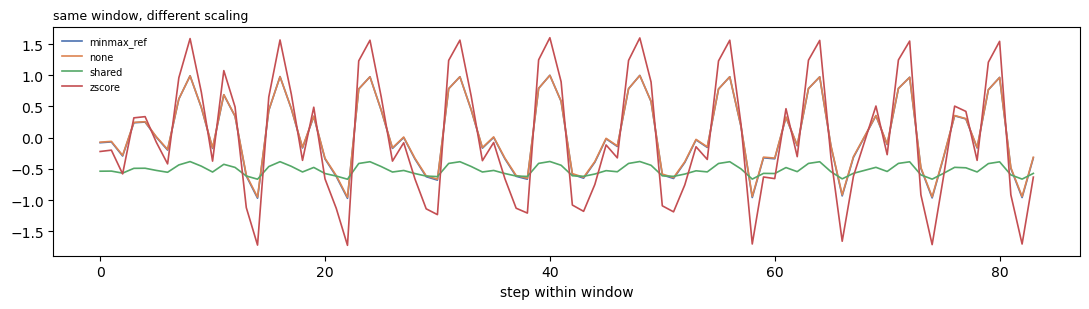

In [6]:
rows, variants = [], {}
for mode in ["minmax_ref", "shared", "none", "zscore"]:
    fw, sc, fl = D.build_windows(world, spec.with_(scaling=mode), cache=D.CACHE)
    rr = D.ref_range_per_client(fw, fl["preprocessing"]["reference_months"])
    variants[mode] = fw
    rows.append({"scaling": mode, "identical_bounds": rr.attrs["identical_bounds"],
                 **{f"{r['client'][-1]}": f"{r['min']:+.2f}..{r['max']:+.2f}"
                    for _, r in rr.iterrows()}})
print(f"reference_months = {fl['preprocessing']['reference_months']} "
      f"(warm-up {world.warmup_months}, first switch {world.first_switch})")
display(pd.DataFrame(rows))

fig, ax = plt.subplots(figsize=(11, 3.2))
F.plot_scaling_compare(ax, variants, index=0, channel=0, client=world.client_names[0])
fig.tight_layout()

## 3. Train one cell

`run_cell` is the single entry point: a **cache read** when the key exists, a train otherwise.
The key is a hash over the normalized spec, the world hash and the resolved sensor set, so
re-running a grid costs nothing and a selection that silently resolves to different sensors shows
up as a new key rather than a corrupted cache hit.

In [7]:
res = run_cell(world, spec, store=store, verbose=True)
res.setdefault("snapshots", res.get("latents_by_round"))

print(f"run_key {res['run_key']}  cache_hit={res['cache_hit']}  {res.get('seconds')}s")
for k in ["prototype_history", "global_prototype_history", "latents_by_round",
          "latent_trajectories", "prototypes", "update_gram", "drift_signals"]:
    v = res.get(k) if res.get(k) is not None else res.get("snapshots")
    print(f"  {k:<26} {None if v is None else v.shape}")

  round   0  loss 0.39559  online 4
  round   1  loss 1.24740  online 4
  round   2  loss 1.22392  online 4
  round   3  loss 1.19467  online 4
  round   4  loss 1.18221  online 4
  round   5  loss 1.18533  online 4
  round   6  loss 1.17349  online 4
  round   7  loss 1.16953  online 4
  round   8  loss 1.16530  online 4
  round   9  loss 1.15973  online 4
  round  10  loss 1.15697  online 4
  round  11  loss 1.15376  online 4
  round  12  loss 1.14221  online 4
  round  13  loss 1.13511  online 4
  round  14  loss 1.12969  online 4
run_key 70e0fc12832b  cache_hit=False  31.8s
  prototype_history          (3900, 63)
  global_prototype_history   (1005, 63)
  latents_by_round           (9072, 69)
  latent_trajectories        (1548, 67)
  prototypes                 (5945, 65)
  update_gram                (150, 6)
  drift_signals              (260, 4)


### 3a. The artifact contract

The check that matters is `prototypes == eval-mode mean latent`: `extract_prototypes` on a
client's final model must reproduce the per-month mean of `latent_trajectories`, i.e.
prototypes and the latent table are the same object computed the same way. The
trainer-dependent rows only appear on a fresh train (a cache hit has no trainer), which is
correct — pass `overwrite=True` to exercise them.

In [8]:
checks = M.check_run(res, world)
assert checks["passed"].all(), checks[~checks["passed"]]
checks

,check,value,passed
0,latent_dim,60,True
1,prototype_dim,60,True
2,latent_rows == windows,1548,True
3,latents_finite,True,True
4,prototypes_finite,True,True
5,proto_rows,1300,True
6,global_proto_rounds,5,True
7,snapshots have pre and post,"[post, pre]",True
8,init-phase snapshot rows,1680,True


### 3b. What the refactor bought: the prototype family + stratified snapshots

Three scopes of the same object, plus a fourth computed over *all* windows rather than the
snapshot subset:

| scope | what | source |
|---|---|---|
| `local` | per-client per-month mean latent, **pre-FedAvg** | `prototype_history` |
| `global` | FINCH cluster centroids per month, server side | `global_prototype_history` |
| `post_fedavg` | same, under the **global** weights | snapshots with `stage=post` |
| `post_fedavg_full` | ditto, all windows, final round | `latent_trajectories` |

`post_fedavg` previously existed only at the final round. With the post-FedAvg hook it exists
at every snapshot round, so the local/global asymmetry is measurable over the round axis
rather than once at the end.

Snapshots are month-stratified: the notebooks sampled uniformly over the timeline, which gave
the six label-clean init months roughly a fifth of the points.

In [9]:
snaps, protos = res["snapshots"], res["prototypes"]
display(protos.groupby("scope").agg(rows=("month", "size"), rounds=("round", "nunique")))
print(f"fedavg_gap (mean cosine distance local -> post_fedavg): "
      f"{__import__('fedwater_lab.train', fromlist=['x']).fedavg_gap(protos):.4f}\n")

display(snaps.groupby(["round", "stage"]).size().unstack("stage"))
print("snapshot rows per month (stratification check, round 0 / stage pre):")
display(snaps[(snaps["round"] == 0) & (snaps["stage"] == "pre")]
        .groupby(["district", "month"]).size().unstack("month").iloc[:, :10])

,rows,rounds
scope,,
global,335,5
local,1300,5
post_fedavg,780,3
post_fedavg_full,260,1


fedavg_gap (mean cosine distance local -> post_fedavg): 0.0085



stage,post,pre
round,,
-1,NaN,1296.0
0,1296.0,1296.0
2,1296.0,1296.0
4,1296.0,1296.0


snapshot rows per month (stratification check, round 0 / stage pre):


month,0,1,2,3,4,5,6,7,8,9
district,,,,,,,,,,
District_A,5,5,5,5,5,5,5,5,5,5
District_B,5,5,5,5,5,5,5,5,5,5
District_C,5,5,5,5,5,5,5,5,5,5
District_D,5,5,5,5,5,5,5,5,5,5


## 4. Score

Scores live in a separate store layer keyed back to `run_key`, so a new method is scored over
the whole existing grid with no GPU. Nothing here ranks cells on drift.

`round = 9999` is the final model over all windows, which is not a snapshot round. Note
`probe_district` sits near 1.0 already at round `-1` (the untrained control): a random
projection separates clients, which is why the controlled probes exist.

In [10]:
lm = M.score_run(res, world)
store.save_scores("latent_metrics", lm, keys=("world_hash", "run_key", "round", "stage"))
lm[["round", "stage", "n", "sil_district", "sil_month", "probe_district",
    "probe_month", "chance_month", "pca90", "eff_dim"]].round(3)

,round,stage,n,sil_district,sil_month,probe_district,probe_month,chance_month,pca90,eff_dim
0,-1,pre,1296,0.139,-0.260,1.0,0.010,0.015,5,3.198
1,0,pre,1296,0.324,-0.229,1.0,0.010,0.015,6,3.755
2,2,pre,1296,0.064,-0.219,1.0,0.010,0.015,7,4.644
3,4,pre,1296,0.073,-0.210,1.0,0.010,0.015,7,4.733
4,9999,final_all_windows,1548,0.124,-0.222,1.0,0.006,0.017,6,3.551


In [11]:
ctrl = M.probe_controlled(snaps[(snaps["round"] == snaps["round"].max())
                                & (snaps["stage"] == "pre")], world, phase="init")
pd.Series(ctrl).round(4).to_frame("value")

c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklea

,value
n,1296.0000
month_within_district,0.0102
chance_month_within,0.0204
regime_lodo,NaN
regime_lodo_p,NaN
regime_lodo_null,NaN
regime_lodo_folds,0.0000


### 4a. Similarity — one `(scope, round, phase)` slice at a time

Enforced by assertion, not convention. In `prototype_history` the round explains the large
majority of the variance, because all clients' prototypes migrate together as training
proceeds; a matrix computed over the stacked table measures training progress, not client
identity. So round is a **loop axis you watch**.

Read `gap_lift` (real minus shuffle-null mean), not the raw gap, and mind `p_floor`: with 5
clients the exhaustive label-shuffle null has 10 distinct assignments for a 3–2 split (floor
0.10) and 5 for a 4–1 split (floor 0.20). A 4–1 world can never be individually significant.
`sd_offdiag` flags degeneracy: after the deconfounding the mean off-diagonal cosine is pinned
near `-1/(N-1)`, so spread is the readable quantity, never the mean.

In [12]:
sim, clu = C.score_run(res, world,
                       methods=("proto_cos", "proto_cos_dc", "drift_sig", "update_cos"),
                       scopes=("local", "post_fedavg"))
store.save_scores("similarity", sim)
store.save_scores("clusters", clu)

(clu.drop_duplicates(["scope", "round", "phase", "method"])
    [["scope", "round", "phase", "method", "regime_gap", "gap_lift", "gap_p",
      "p_floor", "ari", "sd_offdiag"]]
    .sort_values(["phase", "method", "round"]).round(3).to_string(index=False))

'      scope  round phase       method  regime_gap  gap_lift  gap_p  p_floor  ari  sd_offdiag\n      local      0 final    drift_sig       0.000     0.000   1.00     0.25  0.0       0.000\npost_fedavg      0 final    drift_sig       0.000     0.000   1.00     0.25  0.0       0.000\n      local      1 final    drift_sig       0.000     0.000   1.00     0.25  0.0       0.000\n      local      2 final    drift_sig       0.000     0.000   1.00     0.25  0.0       0.000\npost_fedavg      2 final    drift_sig       0.000     0.000   1.00     0.25  0.0       0.000\n      local      3 final    drift_sig       0.000     0.000   1.00     0.25  0.0       0.000\n      local      4 final    drift_sig       0.000     0.000   1.00     0.25  0.0       0.000\npost_fedavg      4 final    drift_sig       0.000     0.000   1.00     0.25  0.0       0.000\n      local      0 final    proto_cos       0.299     0.299   0.25     0.25  0.0       0.152\npost_fedavg      0 final    proto_cos       0.364     0.364

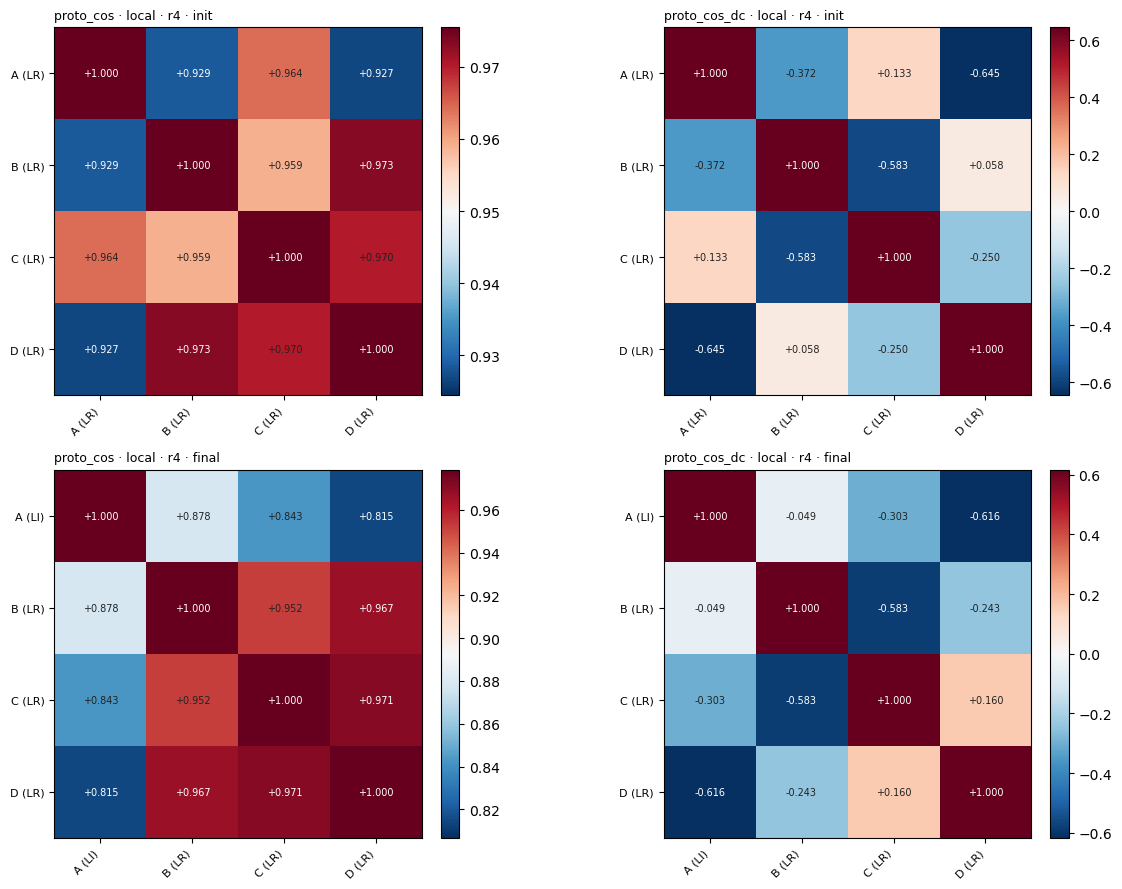

In [13]:
r_last = int(protos[protos["scope"] == "local"]["round"].max())
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for a, (method, phase) in zip(ax.ravel(),
                              [("proto_cos", "init"), ("proto_cos_dc", "init"),
                               ("proto_cos", "final"), ("proto_cos_dc", "final")]):
    S = C.similarity(protos, world, method, "local", r_last, phase,
                     drift_signals=res["drift_signals"], update_gram=res["update_gram"])
    F.plot_similarity(a, S, world.regimes(phase=phase),
                      title=f"{method} · local · r{r_last} · {phase}")
fig.tight_layout()
plt.show()

## 5. Latent space and prototypes

Prototypes are **means** of latents, so they live in the same space and must be read through
the *same* projection as the windows they summarise. `fit_on="windows"` reads them into the
window cloud — but being means they collapse near its centroid and their mutual structure,
which is what the clustering question is about, becomes unreadable. `fit_on="prototypes"`
anchors the same kind of linear map on them and sends the windows through it. Both are one
map applied to both sets.

Marker key: `o` local (pre-FedAvg), `s` post-FedAvg, `P` post-FedAvg over all windows,
`D` global FINCH cluster. `trajectory` joins each client's prototypes in month order.

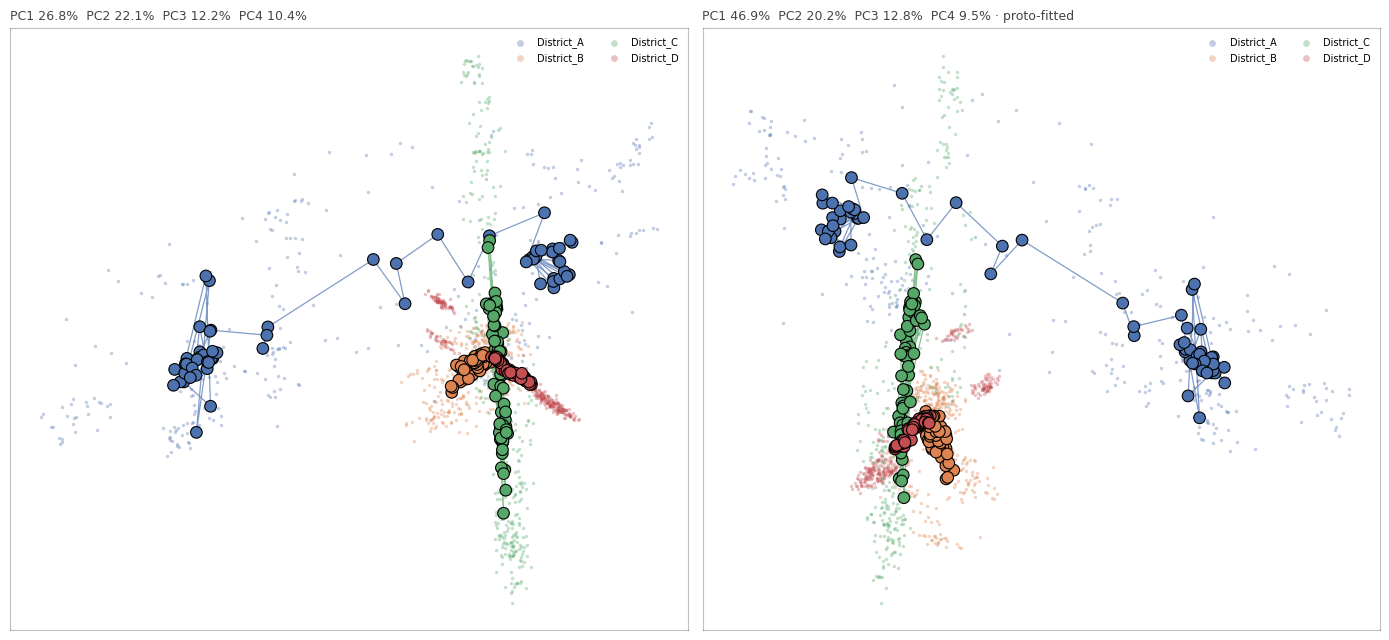

In [14]:
d = (snaps[(snaps["round"] == r_last) & (snaps["stage"] == "pre")]
     .reset_index(drop=True))
pr = protos[(protos["scope"] == "local") & (protos["round"] == r_last)].reset_index(drop=True)
Zp, Zq = d[F.fcols(d)].to_numpy(), pr[F.fcols(pr)].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 6.5))
for a, fit in zip(ax, ["windows", "prototypes"]):
    Ep, Eq, sub = F.project(Zp, Zq, "PCA", 0, fit)
    F.plot_latent(a, d, Ep, pr, Eq, colour_by="district", subtitle=sub, trajectory=True)
    a.legend(fontsize=7, frameon=False, markerscale=2, ncol=2)
fig.tight_layout()

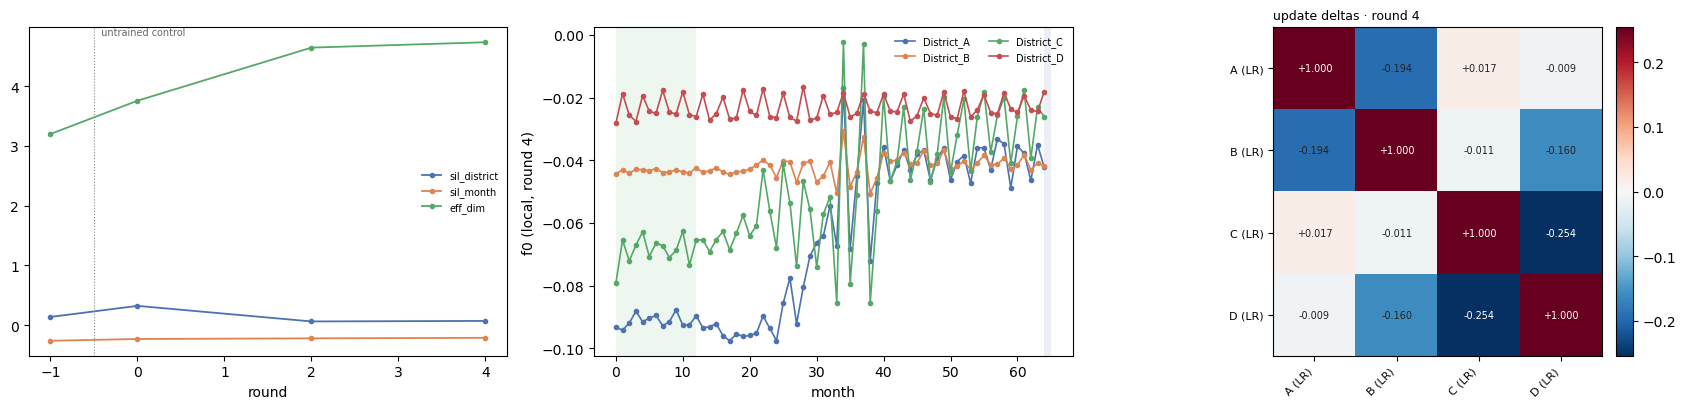

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
F.plot_metrics_by_round(ax[0], M.metrics_by_round(snaps, stage="pre"))
F.plot_prototype_trajectory(ax[1], protos, world, "local", r_last, component=0)
F.plot_update_gram(ax[2], res["update_gram"], r_last, world.regimes(phase="init"))
fig.tight_layout()

## 6. Interactive browsers

`latent_browser` reads persisted tables only, so what you see is what the run saved.
`preprocessing_browser` is the one place that must rebuild windows on a control change, so it
takes an explicit **bounded** cache and only rebuilds when you press *Materialize*. Its sensor
controls are the three filters of §1b; each rebuild prints the selected sensors with their
reasons.

In [16]:
from fedwater_lab import widgets as WGT
_ = WGT.latent_browser(world, res)

In [17]:
_ = WGT.preprocessing_browser(world, spec, cache=D.CACHE)

## 7. Prototype reconstruction — what do the prototypes remember?

A prototype is a mean latent. Decoding it with the trained AER decoder turns it back into a
window, which can be put next to the data it summarises.

**One decoder, several prototypes.** FedAvg overwrites every client's weights with the global
average at the end of **every** round (`FPLTrainer._fedavg`), so after training all client
models and the global model are identical (`check_run`'s `clients_synced_after_fedavg`). What
differs between scopes is the latent vector, not the decoder:

| source | latent | measured under |
|---|---|---|
| `local` | client *c*'s month-*m* mean latent, **pre-FedAvg** | *c*'s personal weights of that round |
| `post_fedavg` | same, **post-FedAvg** (snapshot windows) | the global weights |
| `post_fedavg_full` | same, all windows, final round | the final global weights |
| `finch` | the FINCH centroid *c*'s local prototype belongs to | server side |

All are decoded through the final global model; for `local`, that is a (small) mismatch with
the personal encoder that produced it.

**References**, for client *c*, month *m*, channel *i*, all in model units (aggregated,
scaled), all over **the same windows** (same start steps):

* $T_{c,m}$ — the true mean window of the sensors;
* $D_{k;c,m}$ — district *k*'s total demand, cut at *c*'s window starts, mean-aggregated,
  averaged.

**Metrics** ($z(\cdot)$ = z-score over the window's steps; scaling already removed level, and
a sensor answers demand with a sign and a gain, so only shape is comparable):

* **fidelity** $=\sqrt{\operatorname{mean}_{t,i}(R-T)^2}$ — does the decoded prototype still
  carry the month's waveform?
* $r^2_{\text{own}}=\operatorname{corr}(z(Y_i),z(D_c))^2$ — share of the channel's shape a
  linear map of the own district's demand explains.
* $r^2_{\text{mix}}=\operatorname{corr}(z(Y_i),z(M_i))^2$ with
  $M_i=\sum_k w_{ik}\,z(D_k)$ — the same, for the **mixture-weighted demand shape** the
  sensor is labelled with (shapes are mixed, not volumes: the labels are per-unit shape
  shares).
* **gain** $=r^2_{\text{mix}}-r^2_{\text{own}}$ — does the mixture explain the channel better
  than the own district alone?
* **room** $=1-\operatorname{corr}(z(D_c),z(M_i))^2$ — the most any gain could be. When every
  district in the sensor's mixture shares the own district's regime, $M_i\approx D_c$ and the
  gain is ~0 **by construction**. Read gain only where room is clearly > 0.
* **dtw_gain** $=\mathrm{DTW}(z(Y_i),\pm z(D_c))-\mathrm{DTW}(z(Y_i),\pm z(M_i))$ — the same
  question with dynamic time warping (Sakoe–Chiba band of 2 steps = 6 h, squared cost,
  normalised by $W$), which forgives the small timing shifts (hydraulic lag, aggregation, a
  decoder smearing a peak) that penalise correlation. > 0 ⇒ the mixture is closer.

$Y$ is either the true window $T$ (the **ceiling** the data allows) or a decoded prototype $R$
(what the prototype kept). The expectation: gain > 0 on `mixed` slots with room, ~0 on `pure`
slots, strongest in `final` for sensors that carry weight on the drifted district.

In [18]:
R = int(res["prototypes"].query("scope == 'local'")["round"].max())   # round to decode
model = T.reconstruction_model(res, world, store=store)

fw, _, fl = D.build_windows(world, spec, cache=D.CACHE)   # the windows the run used
true = RC.true_windows(fw)
demand = RC.demand_windows(world, fw, fl)
channels = RC.channel_table(world, fw)

protos_R = res["prototypes"][res["prototypes"]["round"] == R]
recon_long = T.reconstruct_prototypes(model, protos_R)
membership = RC.finch_membership(res["prototypes"], R)
sources = {s: RC.as_arrays(recon_long, s, R)
           for s in ("local", "post_fedavg", "post_fedavg_full")}
sources["finch"] = RC.finch_arrays(recon_long, membership)
sources = {k: v for k, v in sources.items() if v}
print(f"round {R}; decoded sources: { {k: len(v) for k, v in sources.items()} }")
print(f"{len(true)} (client, month) reference windows, "
      f"{int(channels[[c for c in channels if c.startswith('w_')]].notna().all(axis=1).sum())}"
      f" / {len(channels)} channels carry a mixture label")

round 4; decoded sources: {'local': 260, 'post_fedavg': 260, 'post_fedavg_full': 260, 'finch': 260}
260 (client, month) reference windows, 16 / 16 channels carry a mixture label


**Self-check.** `T.decode` is `AER.forward`'s decoder half, run standalone on a latent. On real
windows it must reproduce what `forward` itself returns (`ry`, `y`, `fy`); if not, nothing
below can be trusted.

In [19]:
import torch
c0 = world.client_names[0]
x = torch.as_tensor(fw[c0]["windows"][:8, 1:-1], dtype=torch.float32)
with torch.no_grad():
    ry, y, fy, z = model(x)
dec = T.decode(model, z.numpy())
for name, a, b in (("ry", dec[:, 0], ry), ("y", dec[:, 1:-1], y), ("fy", dec[:, -1], fy)):
    assert np.allclose(a, b.numpy(), atol=1e-5), f"decode != forward on {name}"
print(f"decode reproduces forward on {len(x)} windows: OK  (window {dec.shape[1]}, "
      f"{dec.shape[2]} channels)")

decode reproduces forward on 8 windows: OK  (window 84, 4 channels)


### 7a. Fidelity, per phase

Mean `rmse` of each decoded source against the true mean window. A source that is much worse
in one phase has stopped representing that phase's waveform.

In [20]:
FID = RC.fidelity_table(sources, true, world)
display(FID.pivot_table(index="source", columns="phase", values="rmse", aggfunc="mean")
           .reindex(columns=[p for p in RC.PERIODS if p in set(FID["phase"])]).round(3))

phase,init,transition,final
source,,,
finch,0.457,0.472,0.495
local,0.456,0.467,0.487
post_fedavg,0.457,0.467,0.487
post_fedavg_full,0.457,0.467,0.487


### 7b. Month by month, per client — interactive

Pick a client, a channel (its label shows slot, sensor, class and label mixture), and either
one **month** or a **phase mean** (every array averaged over that phase's months). Black is
the sensors' true mean window; coloured lines are the decoded prototypes; dotted lines are the
own-district and mixture-weighted demand **shapes**, drawn on the channel's scale with the sign
of their correlation (display only — the metrics use z-scores). The tables underneath are the
§7d/§7a numbers for exactly that selection.

In [21]:
RET = RC.retrieval_table({"true": true, **sources}, demand, channels, world, band=2)
_ = WGT.reconstruction_browser(world, sources, true, demand, channels, RET, FID)

### 7c. FINCH cluster prototypes

The server clusters each month's local prototypes (cosine FINCH) and trains against the
centroids. Only the centroids are persisted, so membership is recovered as each local
prototype's **nearest centroid by cosine** (`cos` = that similarity; `n_members` = clients in
the cluster that month; `n_clusters` = centroids that month). The browser draws each decoded
centroid (thick) with the true mean windows of its members (thin, same colour): a centroid that
sits between very different member windows is averaging regimes away.

In [ ]:
display(membership.groupby("month")
        .agg(n_clusters=("n_clusters", "first"), mean_cos=("cos", "mean"),
             members=("client", lambda s: ", ".join(sorted(s))))
        .round(3).T)
_ = WGT.finch_browser(recon_long, membership, true, channels)

month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64
n_clusters,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
mean_cos,0.982,0.98,0.982,0.987,0.98,0.982,0.986,0.991,0.982,0.987,0.979,0.983,0.986,0.979,0.982,0.984,0.98,0.981,0.984,0.98,...,0.962,0.964,0.967,0.963,0.963,0.966,0.964,0.963,0.966,0.963,0.961,0.965,0.96,0.961,0.966,0.963,0.964,0.966,0.962,0.963
members,"District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D",...,"District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D","District_A, District_B, District_C, District_D"


### 7d. Focus by phase — init / transition / final

`separability` is $1-$ mean pairwise shape correlation of the district demand windows: ~0 when
every district runs the same regime (nothing for a mixture to separate), rising once the
drifted district's shape departs. The summaries are means over (client, month, channel) per
source, phase, kind and slot class; `n` is the row count.

,count,mean,std,min,25%,50%,75%,max
phase,,,,,,,,
final,4.0,0.422,0.00,0.422,0.422,0.422,0.422,0.422
init,48.0,0.000,0.00,0.000,0.000,0.000,0.000,0.001
transition,208.0,0.108,0.14,0.000,0.004,0.035,0.183,0.408


,source,phase,kind,slot_class,room,r2_own,r2_mix,gain,dtw_gain,n
0,finch,init,flow,mixed,0.000,0.003,0.003,-0.000,-0.000,96
1,finch,transition,flow,mixed,0.101,0.008,0.006,-0.001,0.001,416
2,finch,final,flow,mixed,0.357,0.025,0.023,-0.002,0.020,8
3,finch,init,flow,pure,-0.000,0.004,0.004,-0.000,-0.000,96
4,finch,transition,flow,pure,-0.000,0.008,0.008,0.000,-0.000,416
5,finch,final,flow,pure,-0.000,0.025,0.025,0.000,-0.000,8
6,local,init,flow,mixed,0.000,0.003,0.003,-0.000,-0.000,96
7,local,transition,flow,mixed,0.101,0.008,0.006,-0.001,-0.001,416
8,local,final,flow,mixed,0.357,0.025,0.023,-0.002,0.012,8
9,local,init,flow,pure,-0.000,0.004,0.004,0.000,-0.000,96


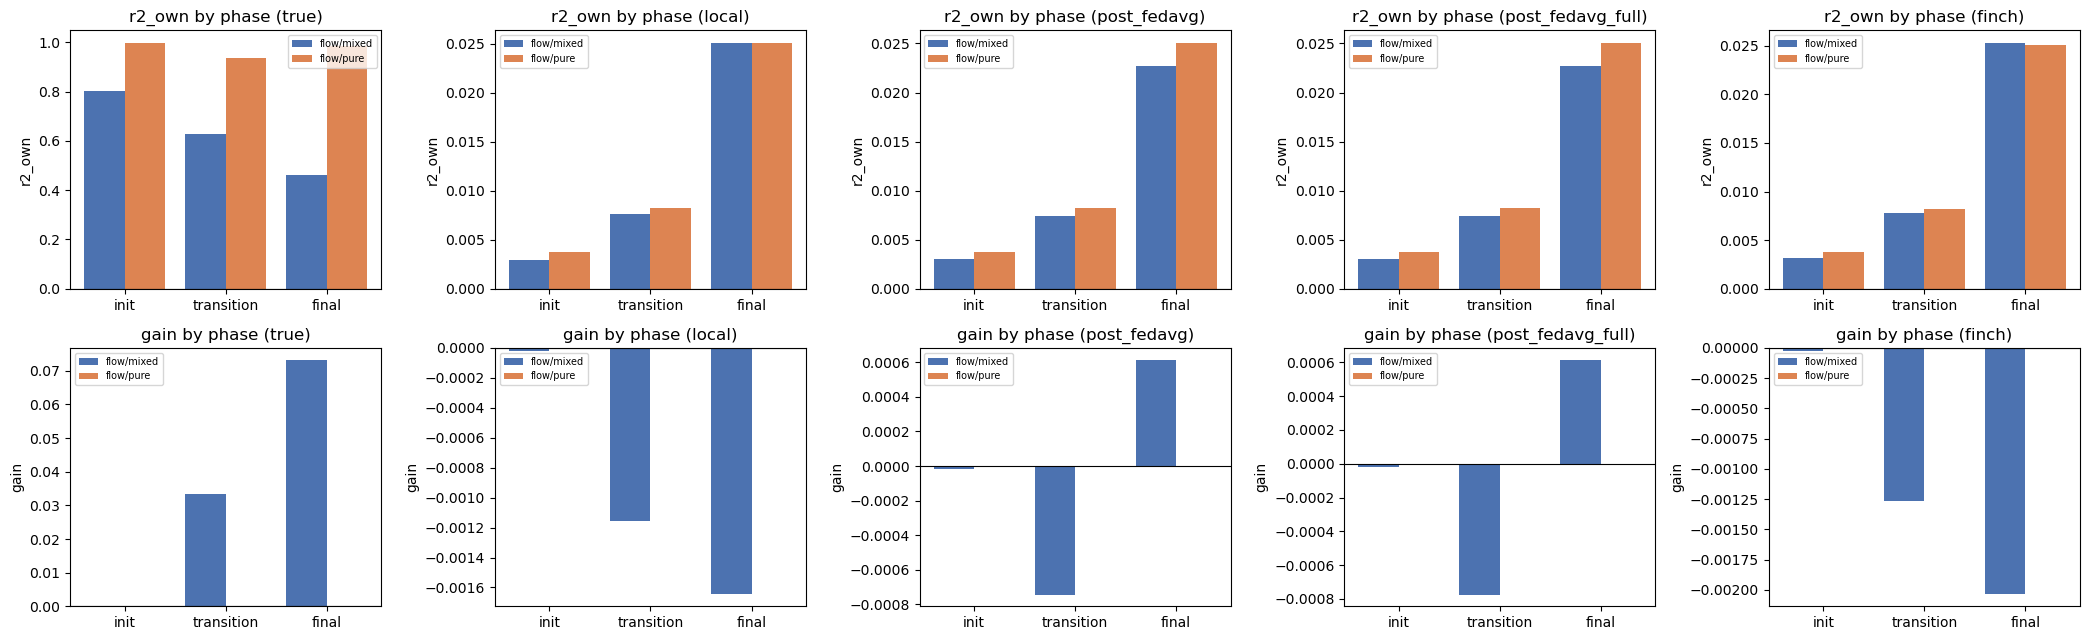

In [23]:
SEP = RC.separability(demand, world)
display(SEP.groupby("phase")["separability"].describe().round(3))

SUM = RC.phase_summary(RET)
display(SUM[["source", "phase", "kind", "slot_class", "room", "r2_own", "r2_mix", "gain",
             "dtw_gain", "n"]].round(3))

srcs = ["true"] + [s for s in sources]
fig, axes = plt.subplots(2, len(srcs), figsize=(4.2 * len(srcs), 6.5), squeeze=False)
for j, s in enumerate(srcs):
    F.plot_retrieval_summary(axes[0][j], SUM, "r2_own", s)
    F.plot_retrieval_summary(axes[1][j], SUM, "gain", s)
fig.tight_layout()
plt.show()

### 7e. Can the prototypes retrieve the mixed demand?

Restricted to the rows where the question is answerable (`room` > 0.1), mixed slots only. Read
the `true` rows first — they are the ceiling: if the mixture does not beat the own district
on the sensors' own data, no prototype can. Then compare each decoded source with that
ceiling: a source that keeps the gain kept the mixture; one that loses it averaged it away.
`dtw_gain` is the same comparison with timing slack.

Two approaches, deliberately simple for a first POC: (1) **linear shape mix**
($r^2$), (2) the same mix under **DTW alignment**. Natural next steps, not done here: fit the
weights per sensor by non-negative least squares on $z(D_k)$ and compare the fitted
weights with the labels; lagged / band-limited mixing; per-window rather than mean-window
scoring.

In [24]:
ANS = RET[(RET["room"] > 0.1) & (RET["slot_class"] == "mixed")]
if not len(ANS):
    print("no mixed channel has room > 0.1 in this world: every district its mixed sensors "
          "listen to shares the own district's regime, so mixture retrieval is not testable "
          "here. Pick a world whose drifted district appears in mixed sensors' labels "
          "(see §1b, the w_District columns).")
else:
    display(ANS.groupby(["source", "phase", "client", "slot"])
               [["w_own", "room", "r2_own", "r2_mix", "gain", "dtw_own", "dtw_mix",
                 "dtw_gain"]].mean().round(3))
    display(ANS.groupby(["source", "phase"])[["gain", "dtw_gain"]]
               .agg(["mean", lambda x: (x > 0).mean()])
               .rename(columns={"<lambda_0>": "share>0"}).round(3))

w_own   room  r2_own  r2_mix   gain  dtw_own  dtw_mix  dtw_gain
source           phase      client     slot                                                                      
finch            final      District_A q_mixed_0  0.000  0.975   0.100   0.003 -0.097    1.135    1.300    -0.165
                                       q_mixed_1  0.272  0.775   0.086   0.020 -0.067    1.143    1.233    -0.090
                            District_B q_mixed_0  0.000  0.675   0.003   0.084  0.082    1.301    1.132     0.168
                            District_C q_mixed_0  0.437  0.112   0.004   0.024  0.021    1.298    1.223     0.075
                                       q_mixed_1  0.254  0.224   0.003   0.031  0.029    1.304    1.206     0.098
                 transition District_A q_mixed_0  0.000  0.553   0.032   0.003 -0.029    1.236    1.298    -0.062
                                       q_mixed_1  0.272  0.430   0.043   0.010 -0.033    1.223    1.273    -0.050
                            District_B q_mixed_0  0.000  0.379   0.003   0.024  0.021    1.297    1.252     0.045
                            District_C q_mixed_0  0.437  0.104   0.003   0.010  0.006    1.296    1.281     0.015
                                       q_mixed_1  0.254  0.176   0.002   0.018  0.016    1.305    1.256     0.048
local            final      District_A q_mixed_0  0.000  0.975   0.096   0.000 -0.096    1.104    1.319    -0.215
                                       q_mixed_1  0.272  0.775   0.085   0.019 -0.066    1.142    1.234    -0.092
                            District_B q_mixed_0  0.000  0.675   0.004   0.086  0.083    1.300    1.137     0.163
                            District_C q_mixed_0  0.437  0.112   0.005   0.026  0.021    1.296    1.226     0.070
                                       q_mixed_1  0.254  0.224   0.003   0.032  0.029    1.303    1.205     0.098
                 transition District_A q_mixed_0  0.000  0.553   0.028   0.001 -0.027    1.222    1.311    -0.088
                                       q_mixed_1  0.272  0.430   0.044   0.010 -0.034    1.219    1.273    -0.054
                            District_B q_mixed_0  0.000  0.379   0.004   0.025  0.020    1.296    1.257     0.040
                            District_C q_mixed_0  0.437  0.104   0.004   0.010  0.006    1.294    1.280     0.014
                                       q_mixed_1  0.254  0.176   0.002   0.018  0.015    1.304    1.256     0.048
post_fedavg      final      District_A q_mixed_0  0.000  0.975   0.078   0.001 -0.077    1.116    1.253    -0.138
                                       q_mixed_1  0.272  0.775   0.085   0.019 -0.066    1.142    1.235    -0.093
                            District_B q_mixed_0  0.000  0.675   0.003   0.085  0.081    1.300    1.137     0.163
                            District_C q_mixed_0  0.437  0.112   0.005   0.026  0.021    1.297    1.227     0.070
                                       q_mixed_1  0.254  0.224   0.003   0.032  0.029    1.303    1.205     0.098
                 transition District_A q_mixed_0  0.000  0.553   0.024   0.001 -0.023    1.186    1.287    -0.101
                                       q_mixed_1  0.272  0.430   0.044   0.010 -0.034    1.219    1.273    -0.055
                            District_B q_mixed_0  0.000  0.379   0.004   0.025  0.021    1.296    1.254     0.043
                            District_C q_mixed_0  0.437  0.104   0.005   0.011  0.006    1.294    1.281     0.013
                                       q_mixed_1  0.254  0.176   0.002   0.018  0.015    1.304    1.256     0.048
post_fedavg_full final      District_A q_mixed_0  0.000  0.975   0.078   0.001 -0.077    1.116    1.253    -0.138
                                       q_mixed_1  0.272  0.775   0.085   0.019 -0.066    1.142    1.235    -0.093
                            District_B q_mixed_0  0.000  0.675   0.003   0.085  0.081    1.300    1.137     0.163
                            District_C q_mixed_0  0.437  0.1

gain         dtw_gain        
                              mean share>0     mean share>0
source           phase                                     
finch            final      -0.007   0.600    0.017   0.600
                 transition -0.009   0.462   -0.013   0.473
local            final      -0.006   0.600    0.005   0.600
                 transition -0.010   0.366   -0.023   0.452
post_fedavg      final      -0.002   0.600    0.020   0.600
                 transition -0.008   0.376   -0.027   0.398
post_fedavg_full final      -0.002   0.600    0.020   0.600
                 transition -0.008   0.366   -0.032   0.387
true             final       0.153   0.600    0.202   0.800
                 transition  0.162   0.613    0.114   0.613

## 8. A grid, and the retention policy

`expand` takes a base spec and dotted axes. Re-running is a disk-cache read. Sensor selection
is an axis like any other — here, pure-only against pure+mixed slots.

`disk_usage` is the input to the weight-retention decision: the dominant artifact is
`latents_by_round`, not `fed_model`, so the dial that matters is snapshot resolution. Keep
`keep_weights="final"` (the default) — §7 needs the final weights to decode.

In [25]:
# GRID = expand(spec, {"classes": [("pure",), ("pure", "mixed")],
#                      "scaling": ["minmax_ref", "shared"]})
# print(f"{len(GRID)} cells")
# ran, fails = run_grid(world, GRID, store=store)
# if len(fails):
#     display(fails)
# display(store.index(world.sim_hash)[["run_key", "kinds", "classes", "transform",
#                                      "scaling", "rounds", "n_windows", "seconds"]])
# store.disk_usage(world.sim_hash)

In [26]:
# # Re-score the whole grid from disk -- no retraining, no GPU.
# rows = []
# for r in store.index(world.sim_hash).itertuples():
#     saved = store.load_run(r.world_hash, r.run_key)
#     saved["snapshots"] = saved.get("latents_by_round")
#     _, clu_i = C.score_run(saved, world, run_key=r.run_key,
#                            methods=("proto_cos", "proto_cos_dc"), scopes=("local",))
#     if len(clu_i):
#         rows.append(clu_i.assign(classes=r.classes, scaling=r.scaling))
# allclu = pd.concat(rows, ignore_index=True)
# store.save_scores("clusters", allclu)

# (allclu[allclu["round"] == allclu["round"].max()]
#  .drop_duplicates(["classes", "scaling", "phase", "method"])
#  .pivot_table(index=["classes", "scaling"], columns=["phase", "method"],
#               values="gap_lift")
#  .round(3))

## What is deliberately left open

* **Power.** Few clients and 2 tokens keep the exhaustive-null p-floor high. More worlds,
  3-token maps, or a finer scoring unit are the fix, not refactoring.
* **Label-clean months.** Longer warm-up and post-drift stretches are the prerequisite for
  the init-state question and for §7's `final` rows.
* **Reconstruction is linear and mean-window.** One decoder for every scope, lag-free
  mixing, labels measured on weekly profiles under a probe excitation that can differ from the
  world's drift. NNLS weight recovery, lagged mixing and per-window scoring are the next steps.
* **FINCH membership is recovered, not recorded.** Persisting FINCH's own assignment in the
  trainer would remove the nearest-centroid step.
* **Common-mode contamination.** Visible as raw `proto_cos` near 0.97 for every pair.
  Hydraulic coupling, pinned for later.
* **Asymmetric hand-picked selections.** `include` / `exclude` can give clients different slot
  sets; the frames builder warns, because channel *i* then means different sensors in
  different clients and global / FINCH prototypes stop being comparable channel by channel.